In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from src.data.utils.sparsity import parquet_coverage_report

In [20]:
base_path = Path("../data/coinbase/ohlcv")

In [ ]:
report = parquet_coverage_report(
    base_path=base_path,
    symbols=["aave-usdc"],
    years=["2026"],
    months=[1, 2],
    # timeframes=["5m"],
)

In [92]:
filtered_report = report.filter(
    pl.col("ratio") < 0.5,
    # pl.col("ratio") < 0.9
)
filtered_report.head(100)

symbol,year,month,timeframe,row_count,max_possible,ratio
str,str,str,str,i64,i64,f64
"""aave-usdc""","""2026""","""feb""","""1m""",6576,40320,0.16
"""algo-usdc""","""2026""","""feb""","""1m""",1596,40320,0.03
"""ape-usdc""","""2026""","""jan""","""1m""",6194,44640,0.13
"""ape-usdc""","""2026""","""feb""","""1m""",0,40320,0.0
"""ape-usdc""","""2026""","""feb""","""5m""",3768,8064,0.46
…,…,…,…,…,…,…
"""snx-usdc""","""2026""","""jan""","""1m""",9667,44640,0.21
"""snx-usdc""","""2026""","""feb""","""1m""",0,40320,0.0
"""uni-usdc""","""2026""","""feb""","""1m""",4935,40320,0.12


In [35]:
df = pl.read_parquet(f"{base_path}/pepe-usdc/1m/2026/01.parquet")

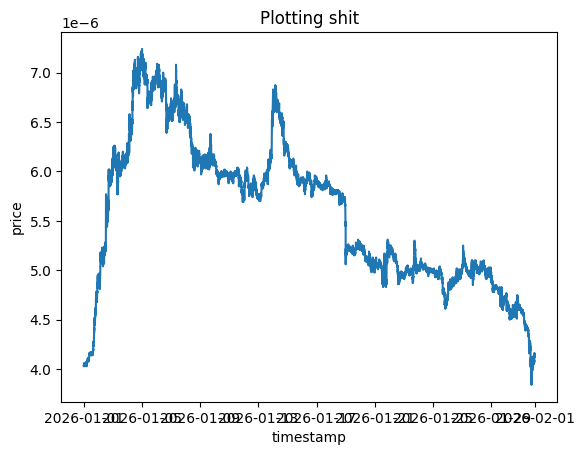

In [36]:
# Pass the timestamp series as X and the close series as Y
df = df.sort("timestamp")
plt.plot(df["timestamp"], df["close"])

plt.xlabel("timestamp")
plt.ylabel("price")
plt.title("Plotting shit")
plt.show()